In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("cc_info.csv")


In [27]:
df.shape

(984, 5)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   credit_card        984 non-null    int64 
 1   city               984 non-null    object
 2   state              984 non-null    object
 3   zipcode            984 non-null    int64 
 4   credit_card_limit  984 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 38.6+ KB


In [29]:
df.describe()

,credit_card,zipcode,credit_card_limit
count,9.840000e+02,984.000000,984.000000
mean,5.410432e+15,17895.316057,12321.138211
std,2.545234e+15,23778.651105,7398.449174
min,1.003715e+15,690.000000,2000.000000
25%,3.316062e+15,3280.000000,7000.000000
50%,5.365218e+15,5820.000000,10000.000000
75%,7.562153e+15,18101.250000,16000.000000
max,9.999757e+15,98401.000000,55000.000000


In [30]:
df.isnull().sum()

credit_card          0
city                 0
state                0
zipcode              0
credit_card_limit    0
dtype: int64

In [31]:
df.drop("credit_card", axis=1, inplace=True)

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["city"] = le.fit_transform(df["city"])

df["state"] = le.fit_transform(df["state"])

In [33]:
df.head()

,city,state,zipcode,credit_card_limit
0,29,26,18612,6000
1,50,26,15342,16000
2,6,14,1501,14000
3,84,34,26412,18000
4,78,23,10001,20000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   city               984 non-null    int64
 1   state              984 non-null    int64
 2   zipcode            984 non-null    int64
 3   credit_card_limit  984 non-null    int64
dtypes: int64(4)
memory usage: 30.9 KB


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [36]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

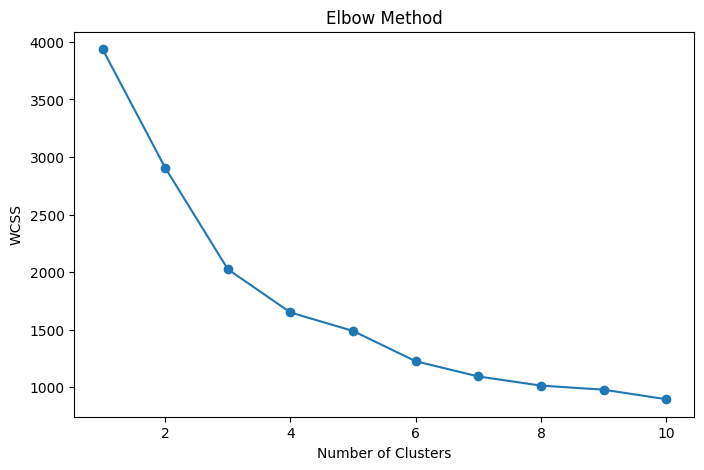

In [37]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [38]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [39]:
df["Cluster"] = clusters

print(df.head())

   city  state  zipcode  credit_card_limit  Cluster
0    29     26    18612               6000        1
1    50     26    15342              16000        1
2     6     14     1501              14000        1
3    84     34    26412              18000        1
4    78     23    10001              20000        1


In [40]:
print(df["Cluster"].value_counts())

Cluster
0    501
1    321
2    162
Name: count, dtype: int64


In [41]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.3845210927555615


In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

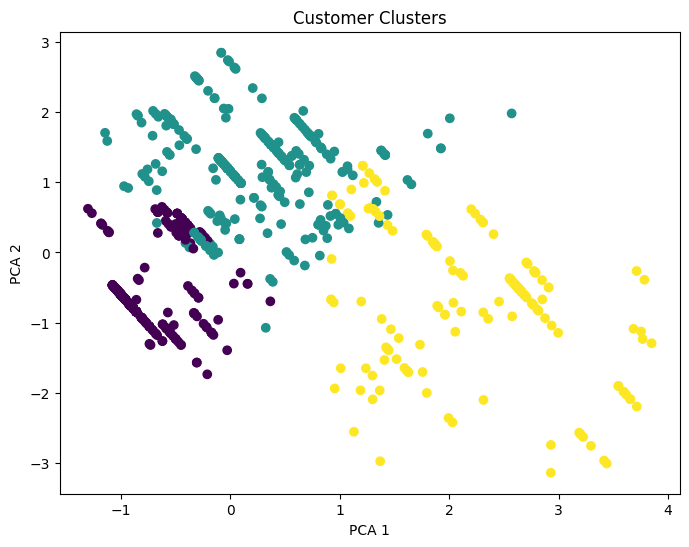

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title("Customer Clusters")

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.show()

In [45]:
print(df.groupby("Cluster").mean())

               city      state       zipcode  credit_card_limit
Cluster                                                        
0        111.520958  20.113772   4436.369261       11626.746507
1         42.115265  25.320872  15468.059190       13267.912773
2         61.117284  12.629630  64327.919753       12592.592593
